In [30]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [31]:
class BMI(TypedDict):
    weight: float  # in kg
    height: float  # in meters
    BMI: float
    category: str

In [32]:
graph=StateGraph(BMI)

Nodes

In [33]:
def calculation(state: BMI) -> BMI:
    weight = state['weight']
    height = state['height']
    bmi_value = weight / (height ** 2)
    state['BMI'] = round(bmi_value, 2)
    return state

In [34]:
def labelling(state: BMI) -> BMI:
    bmi_value = state['BMI']
    if bmi_value < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi_value < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi_value < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [35]:
graph.add_node('calculation',calculation)
graph.add_node('labelling',labelling)

Edges

In [36]:
graph.add_edge(START,'calculation')
graph.add_edge('calculation','labelling')
graph.add_edge('labelling',END)

In [37]:
workflow= graph.compile()

In [38]:
initial_state = {'weight': 70, 'height': 1.75}
output= workflow.invoke(initial_state)

In [39]:
print(output)

{'weight': 70, 'height': 1.75, 'BMI': 22.86, 'category': 'Normal weight'}


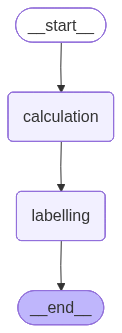

In [41]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())